In [ ]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_excel("/content/edufeed_clean_data.xlsx")

In [12]:
df = df[['comments','student_star']]

In [14]:
 def get_sentiment(star):
  if star >= 4:
    return 'positive'
  elif star >= 3:
    return 'Neutral'
  else:
    return ' Negative'

df['sentiment'] = df['student_star'].apply(get_sentiment)

In [16]:
print (df['sentiment'])

0         positive
1         positive
2         positive
3         positive
4         positive
           ...    
19976     Negative
19977     Negative
19978     positive
19979     positive
19980     positive
Name: sentiment, Length: 19981, dtype: object


In [19]:
from sklearn.model_selection import train_test_split

X = df['comments'].fillna('').astype(str)
y = df['sentiment']

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,2),stop_words='english')

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression


In [22]:
model = LogisticRegression(max_iter=100)
model.fit(X_train_vec,y_train)

LogisticRegression()

In [23]:
y_pred = model.predict(X_test_vec)

In [24]:
from sklearn.metrics import accuracy_score,classification_report

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.7673254941205905
              precision    recall  f1-score   support

    Negative       0.76      0.71      0.73      1134
     Neutral       0.39      0.08      0.13       501
    positive       0.78      0.94      0.85      2362

    accuracy                           0.77      3997
   macro avg       0.65      0.58      0.57      3997
weighted avg       0.73      0.77      0.73      3997



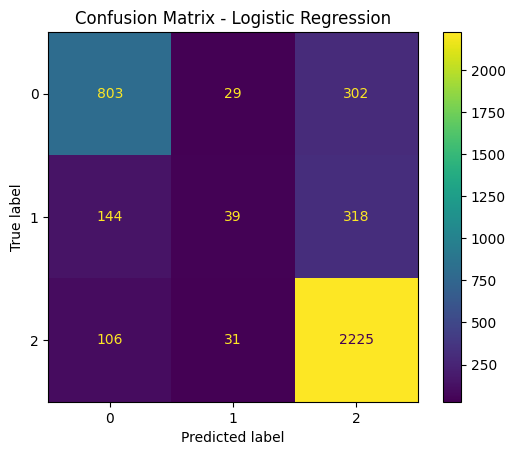

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()